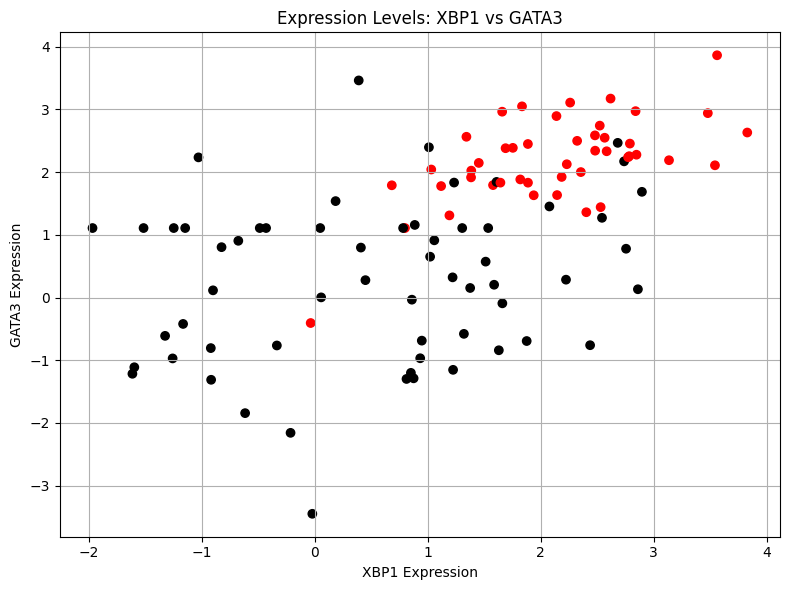

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# Define the paths to the required input files
class_labels_file = './data2/class.tsv'
gene_info_file = './data2/columns.tsv'
expression_data_file = './data2/filtered.tsv'

# Load the binary class labels (1 for ER+, 0 for ER-)
with open(class_labels_file, 'r') as file:
    class_labels = pd.read_csv(file, sep='\t', header=None).iloc[:, 0].values

# Parse gene ID and symbol mapping, skipping comment lines that start with '#'
with open(gene_info_file, 'r') as file:
    mapping_lines = [line for line in file if not line.startswith('#')]

gene_lookup = pd.read_csv(StringIO(''.join(mapping_lines)), sep='\t')

# Load the gene expression matrix (genes as columns, samples as rows)
with open(expression_data_file, 'r') as file:
    expression_df = pd.read_csv(file, sep='\t', index_col=0)

# Clean up the column names to ensure they're formatted correctly
expression_df.columns = expression_df.columns.astype(str).str.strip()

# Get the gene IDs for XBP1 and GATA3
xbp1_gene_id = '4404'  # Predefined XBP1 gene ID
gata3_gene_id = str(gene_lookup[gene_lookup['GeneSymbol'] == 'GATA3']['ID'].values[0])

# Extract expression levels for the selected genes
xbp1_levels = expression_df[xbp1_gene_id].values
gata3_levels = expression_df[gata3_gene_id].values

# Assign colors to samples based on class labels: red for ER+, black for ER-
sample_colors = ['red' if label == 1 else 'black' for label in class_labels]

# Create a scatter plot of GATA3 vs XBP1 expression levels
plt.figure(figsize=(8, 6))
plt.scatter(xbp1_levels, gata3_levels, c=sample_colors)
plt.xlabel('XBP1 Expression')
plt.ylabel('GATA3 Expression')
plt.title('Expression Levels: XBP1 vs GATA3')
plt.grid(True)
plt.tight_layout()
plt.show()


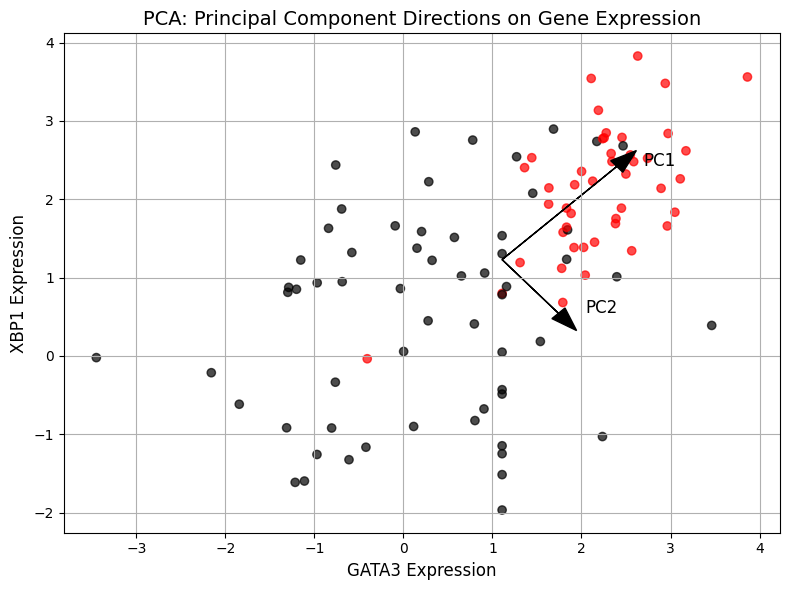

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Combine GATA3 and XBP1 expression data into a single 2D array (samples x genes)
expression_data = np.column_stack((gata3_levels, xbp1_levels))

# Function to apply PCA manually on 2D data
def compute_principal_components(data):
    centered_data = data - np.mean(data, axis=0)
    covariance_matrix = np.cov(centered_data, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    order = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[order]
    sorted_eigenvectors = eigenvectors[:, order]
    return sorted_eigenvectors, sorted_eigenvalues, centered_data

# Run PCA
components, variances, centered = compute_principal_components(expression_data)

# Extract first and second PCs
pc1_vector = components[:, 0]
pc2_vector = components[:, 1]

# Project data
pc1_scores = centered @ pc1_vector
pc2_scores = centered @ pc2_vector

# Flip PC1 if needed
if np.mean(pc1_scores[class_labels == 1]) < np.mean(pc1_scores[class_labels == 0]):
    pc1_vector = -pc1_vector
    pc1_scores = -pc1_scores

# Compute mean expression levels
avg_gata3 = np.mean(gata3_levels)
avg_xbp1 = np.mean(xbp1_levels)

# Scale arrows
pc1_length = np.sqrt(variances[0])
pc2_length = np.sqrt(variances[1])

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(gata3_levels, xbp1_levels, c=sample_colors, alpha=0.7)
plt.arrow(avg_gata3, avg_xbp1, pc1_vector[0]*pc1_length, pc1_vector[1]*pc1_length,
          head_width=0.2, head_length=0.3, color='black')
plt.arrow(avg_gata3, avg_xbp1, pc2_vector[0]*pc2_length, pc2_vector[1]*pc2_length,
          head_width=0.2, head_length=0.3, color='black')
plt.text(avg_gata3 + pc1_vector[0]*pc1_length + 0.3, 
         avg_xbp1 + pc1_vector[1]*pc1_length, 'PC1', fontsize=12)
plt.text(avg_gata3 + pc2_vector[0]*pc2_length + 0.3, 
         avg_xbp1 + pc2_vector[1]*pc2_length, 'PC2', fontsize=12)
plt.xlabel('GATA3 Expression', fontsize=12)
plt.ylabel('XBP1 Expression', fontsize=12)
plt.title('PCA: Principal Component Directions on Gene Expression', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


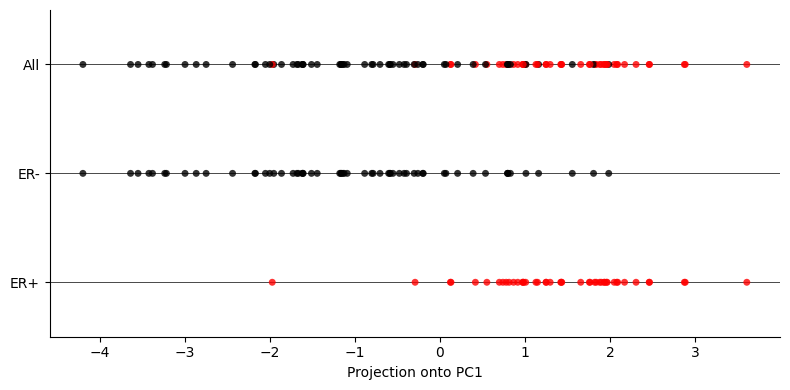

In [5]:
import seaborn as sns

# Create DataFrames for all, ER- and ER+ groups using PC1 projections
pc1_df_all = pd.DataFrame({
    "PC1_Projection": pc1_scores,
    "SampleGroup": "All",
    "GroupColor": sample_colors
})

my_pc1_df_er_neg = pd.DataFrame({
    "PC1_Projection": pc1_scores[class_labels == 0],
    "SampleGroup": "ER-",
    "GroupColor": "black"
})

my_pc1_df_er_pos = pd.DataFrame({
    "PC1_Projection": pc1_scores[class_labels == 1],
    "SampleGroup": "ER+",
    "GroupColor": "red"
})

# Concatenate all group DataFrames
pc1_plot_data = pd.concat([pc1_df_all, my_pc1_df_er_neg, my_pc1_df_er_pos], ignore_index=True)

# Generate the strip plot
plt.figure(figsize=(8, 4))
ax = sns.stripplot(
    data=pc1_plot_data, x="PC1_Projection", y="SampleGroup", hue="GroupColor",
    palette={"black": "black", "red": "red"},
    dodge=False, jitter=False, alpha=0.8, size=5
)

# Grid and labels
ax.yaxis.grid(True, linestyle='-', color='black', linewidth=0.5, alpha=1.0)
plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.legend([], [], frameon=False)  # Remove legend
sns.despine()
plt.tight_layout()
plt.show()
